In [2]:
%load_ext autoreload
%autoreload 2


import sys
sys.path.append("/root/limlab01/kaistai/25DFT/QHFlow/src")
# from common.dft_utils import *
import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import md.scflow_calculator_gpu

from dft_process.dft_process_utils import *
# from common.draw_util import *
import torch
from torch_geometric.loader import DataLoader
from common.units import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


gpu4pyscf is installed.


/root/miniforge3/envs/pyscf-gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO     [dft_process_utils.py:32] >> Source path: /root/limlab01/kaistai/25DFT/QHFlow/src

INFO     [dft_process_utils.py:62] >> Root path: /root/limlab01/kaistai/25DFT/QHFlow

In [3]:
from common.draw_util import *

In [4]:
md17_experiment = MD17Experiment(data_index=5)
md17_experiment.set_model_path()

INFO     [setup.py:66] >> Seed: 0

Seed set to 0


ConfigNamespace({'dataset_name': 'water', 'num_train': 500, 'num_valid': 500, 'density_loss': 0.01, 'max_radius': 15.0, 'batch_size': 16, 'train_batch_size': 16, 'valid_batch_size': 16, 'test_batch_size': 16})


INFO     [dft_process_utils.py:202] >> [!] conf.dataset.dataset_name: rmd-salicylic_acid

use_ref_hamiltonian_as_init_ham: False
rmd17
rmd-salicylic_acid


In [5]:
# cur_ckpt = "/root/25DFT/QHFlow/src/outputs/malondialdehyde/QHFlow_so2_v5_1_small_v2-malondialdehyde/checkpoints/weights-epoch=39-val_loss=0.0000000.ckpt"
cur_ckpt = "/root/25DFT/QHFlow/src/outputs/rmd-salicylic_acid/QHFlow_so2_v5_1_middle_b10-rmd-salicylic_acid/checkpoints/weights-epoch=79-val_loss=0.0000000.ckpt"

In [6]:
pos_conversion = BOHR2ANG
pos_conversion = 1

In [10]:
sample = md17_experiment.dataset[1]

In [23]:
sccalculator = md.scflow_calculator_gpu.SCFlowRKSCalculator()
sccalculator.set_model(cur_ckpt, mf_init_functional="pbe", density_fit=True, model_length_unit="ang", init_density_fit=True)

INFO     [__init__.py:104] >> model_args: {'in_node_features': 1, 'sh_lmax': 4, 'hidden_size': 128,                
         'bottle_hidden_size': 32, 'num_gnn_layers': 3, 'max_radius': 15, 'num_nodes': 10, 'radius_embed_dim': 16, 
         'max_T': 15, 'use_block_S': False, 'use_block_H': False, 'ham_dim': 24, 'ham_hidden': 288, 'dataset_type':
         'qh9', 'num_ham_gnn_layers': 2}

Setting device to cuda


INFO     [base_module.py:128] >> use_init_hamiltonian: False

INFO     [base_module.py:129] >> use_init_hamiltonian_residue: True

INFO     [base_module.py:130] >> ema_start_epoch: -1

INFO     [base_module.py:131] >> qh9: False

INFO     [base_module.py:132] >> test_mode: test

INFO     [flow_module.py:211] >> init_p0_type: expand

model trained on dataset:  rmd-salicylic_acid
ode_steps: 1
Model length unit are not consistent with the model. Model length unit: ang, Model length unit: bohr
max_radius: 1000
max_num_neighbors: 200


In [13]:
rkscalculator = md.scflow_calculator_gpu.RKSCalculator()

In [16]:
properties = ["energy", "forces"]
system_changes = ["positions"]
ase_atoms = md.scflow_calculator_gpu.QHData_to_atoms(sample, unit="ang")

In [24]:
rkscalculator.calculate(ase_atoms, properties, system_changes, units="ang")

{'energy': np.float64(-13472.576511320274),
 'forces': array([[ 1.30744329e-01, -1.25442289e+00, -1.52392899e-01],
        [ 1.33899820e+00,  1.85454536e+00,  8.70621444e-02],
        [ 2.88838438e-01,  1.03045928e+00,  4.98093676e-01],
        [-8.97281753e-02, -1.13001609e+00, -5.07706186e-01],
        [-1.86613743e+00, -4.99925459e-01, -9.75072682e-01],
        [ 2.93209292e+00,  2.55766996e+00, -1.38825593e-01],
        [ 1.25500957e+00,  3.33399892e-01,  9.26931581e-01],
        [-1.84517723e+00, -1.86685239e+00, -4.26168879e-01],
        [ 5.34619737e-01,  1.19095594e-01,  2.26067669e-01],
        [-1.28099971e+00,  7.15537472e-01,  2.50775430e-03],
        [-7.75066603e-01,  6.50646003e-01,  6.79302648e-02],
        [ 4.61979821e-01, -1.03745918e+00,  5.33083329e-01],
        [-1.45941965e+00,  8.47621756e-01, -2.32060548e-02],
        [-6.91774264e-01, -1.69184136e+00, -1.71152844e-01],
        [ 9.63192510e-01, -1.09012413e+00,  3.70537556e-02],
        [ 1.02190894e-01,  4.62

In [26]:
sccalculator.calculate(ase_atoms, properties, system_changes, units="ang", model_length_unit="ang")

{'energy': np.float64(-13472.554199402228),
 'forces': array([[-0.06144714, -1.5164756 , -0.0829784 ],
        [ 1.59891124,  1.92582827,  0.13997439],
        [ 0.17452808,  1.03201239,  0.46901932],
        [-0.1443861 , -0.97322062, -0.48354309],
        [-1.9267459 , -0.57948261, -0.94504029],
        [ 2.90799988,  2.56749778, -0.14822881],
        [ 1.24877239,  0.3364472 ,  0.92227711],
        [-2.01378565, -1.8992732 , -0.45583052],
        [ 0.69058133,  0.40134038,  0.15627902],
        [-1.35243479,  0.68884084,  0.03122936],
        [-0.6222775 ,  0.60929483,  0.05010871],
        [ 0.42870602, -0.97233446,  0.51425639],
        [-1.47181014,  0.83952828, -0.0263822 ],
        [-0.69807034, -1.71896901, -0.17257877],
        [ 1.00163741, -1.18771863,  0.04810988],
        [ 0.23917453,  0.44725913, -0.01444007]])}

In [41]:
sccalculator.calculate(ase_atoms, properties, system_changes, units="ang", model_length_unit="ang",init_ham=sample_init_ham)

{'energy': np.float64(-13472.57647191162),
 'forces': array([[ 1.30129357e-01, -1.26018368e+00, -1.51102895e-01],
        [ 1.34070439e+00,  1.85809132e+00,  8.64553748e-02],
        [ 2.85205449e-01,  1.02738007e+00,  4.97410177e-01],
        [-8.98915864e-02, -1.13025370e+00, -5.07306602e-01],
        [-1.86328946e+00, -4.98137185e-01, -9.75231274e-01],
        [ 2.93095144e+00,  2.56010261e+00, -1.38094002e-01],
        [ 1.25632556e+00,  3.33697952e-01,  9.26657328e-01],
        [-1.84220872e+00, -1.86724185e+00, -4.25709627e-01],
        [ 5.34258092e-01,  1.20050458e-01,  2.25692582e-01],
        [-1.28221329e+00,  7.19426292e-01,  1.32724668e-03],
        [-7.73566180e-01,  6.50776094e-01,  6.78357365e-02],
        [ 4.62225672e-01, -1.03833496e+00,  5.33378147e-01],
        [-1.46062587e+00,  8.47096153e-01, -2.37423758e-02],
        [-6.93137656e-01, -1.69385399e+00, -1.71378160e-01],
        [ 9.63114437e-01, -1.09053165e+00,  3.73566004e-02],
        [ 1.01381403e-01,  4.624

In [ ]:
sccalculator.results["energy"] * 1 / HA2eV

np.float64(-495.1070456615353)

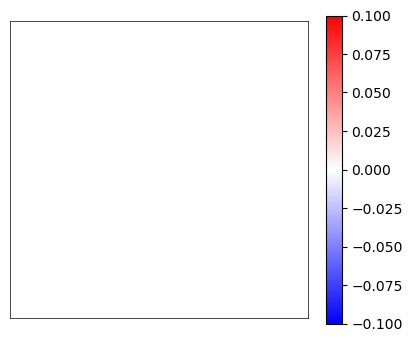

np.float64(0.0)

In [27]:
matshow((rkscalculator.init_ham -  sccalculator.init_ham).get())

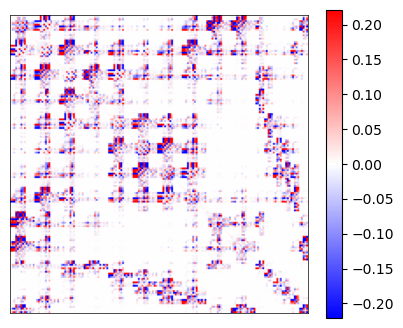

tensor(0.2209)

In [ ]:
matshow(sample.init_ham-sccalculator.init_ham.get())

In [38]:
transform_convention = "e3nn_to_pyscf_def2svp"
sample_init_ham = matrix_transform_single(sample.init_ham, sample.atoms.cpu().squeeze().numpy(), convention=transform_convention).detach().cpu().numpy()

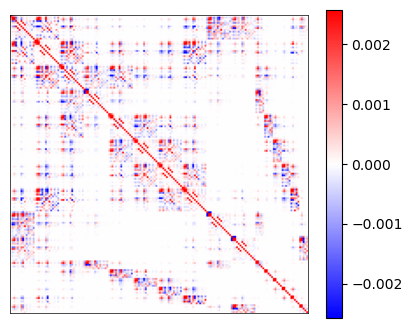

np.float64(0.002566827867080335)

In [39]:
matshow(sample_init_ham-sccalculator.init_ham.get())

In [45]:
mol = sccalculator.get_mol(sample.atoms, sample.pos)

In [67]:
mf2 = dft.RKS(mol).to_gpu()
mf2.xc = "pbe"
mf2.grids.level = 3
# mf2.small_rho_cutoff = 1e-12

In [68]:
init_dm = mf2.get_init_guess(key='minao') # Fixed
init_ham = mf2.get_fock(dm=init_dm)

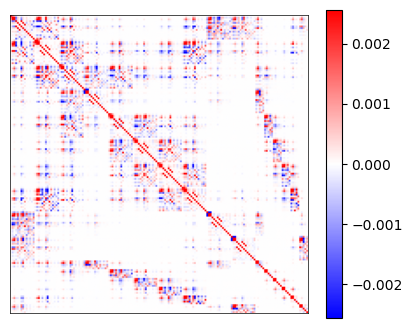

np.float64(0.002566509379945359)

In [70]:
matshow(sample_init_ham-init_ham.get())

In [ ]:
target_ham_db = sample.hamiltonian.detach().cpu().numpy()
target_ham_transformed = matrix_transform_single(torch.tensor(target_ham_db), sample.atoms.cpu().squeeze().numpy(), convention="e3nn_to_pyscf_def2svp").detach().cpu().numpy()
cur_dft.set_ode_steps(1)
pred_ham_untransformed = cur_dft.forward_component(sample.atoms, sample.pos, sample.overlap, sample.init_ham, input_transform=False, output_transform=False)
pred_ham = cur_dft.forward_component(sample.atoms, sample.pos, sample.overlap, sample.init_ham, input_transform=False, output_transform=True)
# pred_ham3 = cur_dft.forward_component(sample.atoms, sample.pos, sample.overlap, sample.init_ham, input_transform=True, output_transform=False)
print(abs(pred_ham-target_ham_transformed).mean())

ode_steps: 1
1.5610035368635608e-06


In [9]:
data_pos = torch.tensor([
    [ 1.21778583, -0.11030699,  0.20167955],
    [-0.45357504,  0.08722384,  0.39345084],
    [-0.33820726,  0.52028511,  0.48008870],
    [-0.36875550,  1.72981577, -0.09696476],
    [-0.02342008,  0.93655019, -0.36763257],
    [-0.94922712, -0.49705040,  0.45988661],
    [-1.61370558, -1.47531916,  0.18499131],
    [-0.12490388, -1.68862331,  0.50617733],
    [ 1.94674566,  0.76824429,  0.40169283],
    [ 1.88986979, -0.24445724, -0.07652804],
    [ 0.05035597, -0.40031069, -1.46880085],
    [-2.79314945,  2.12533740, -0.49256694],
    [-3.33412768,  0.27136040, -0.72860865],
    [-1.86062814, -2.59998790, -1.33305557],
    [ 0.73634016, -2.82055909,  1.07609682],
    [ 0.31304486,  1.34448600, -1.79760000],
], dtype=torch.float32)
# data_pos = sample.pos.cpu().numpy()

data_pos2 = torch.tensor([
    [ 1.62983477, -0.20424105,  0.05204616],
    [ 0.17175189, -0.21022218,  0.10383472],
    [-0.61646020,  0.90222168, -0.08662219],
    [-0.05573198,  2.07953167, -0.14043865],
    [-1.97730947,  0.86597490, -0.10273995],
    [-2.60323429, -0.30793312, -0.24278761],
    [-1.86039042, -1.54373693,  0.00638613],
    [-0.47696131, -1.49277699,  0.06741305],
    [ 2.31505132,  0.87900120,  0.11662529],
    [ 2.31971002, -1.32250702,  0.16463071],
    [ 0.91685718,  1.89700985, -0.00769049],
    [-2.58376479,  1.82036030,  0.25683153],
    [-3.71331358, -0.28743583, -0.38004068],
    [-2.50156069, -2.41532850, -0.00736723],
    [ 0.27667996, -2.33474541,  0.31921631],
    [ 3.22591662, -0.93069673,  0.51059574],
], dtype=torch.float32)
sample.pos = data_pos2

In [10]:
# %%timeit -n 1 -r 10
# sample_mol = cur_dft.get_mol(sample.atoms, sample.pos * BOHR2ANG)
# cur_dft.direct_energy_force(sample_mol, model_length_unit="bohr")

In [11]:
# # sample_mol = cur_dft.get_mol(sample.atoms, sample.pos * pos_conversion)
# print(sample.dft_energy)
# cur_dft.direct_energy_force(sample_mol, model_length_unit="ang", gpu4pyscf=False, filtering=False)

In [12]:
# sample_mol = cur_dft.get_mol(sample.atoms, sample.pos * pos_conversion)
sample_mol = cur_dft.get_mol(sample.atoms, data_pos * pos_conversion)
print(sample.dft_energy)
cur_dft.direct_energy_force(sample_mol, model_length_unit="ang", gpu4pyscf=False, filtering=False)

tensor([[-13472.5726]])


(np.float64(-469.43582140049307),
 array([[-1.03339589e+02,  2.16319346e+01,  1.17226736e+02],
        [-6.79036870e+02, -1.62383585e+02, -4.00293397e+02],
        [ 4.69868082e+02,  3.18591653e+01, -7.88628022e+02],
        [ 3.19487593e+00, -4.34463475e+01,  6.17856765e+01],
        [-1.10758178e+02, -4.06153870e+01,  5.42982887e+02],
        [ 4.14167860e+02, -1.36384305e+01,  4.76726092e+02],
        [ 6.75007387e+01,  1.76721723e+02, -9.26812620e+01],
        [-3.57059622e+01, -2.46428054e+01,  2.23063504e+01],
        [-3.50619006e+01,  1.58491585e+01, -1.32261261e+01],
        [ 4.48684533e+00, -8.28500185e+00,  1.11172124e+01],
        [-2.45787477e+01,  7.86548516e+00,  2.08272248e+01],
        [ 2.90102136e+00, -7.96632162e-01, -1.61312302e+00],
        [ 2.34532617e+01,  1.58719462e+00,  1.09177582e+01],
        [ 6.34256725e+00,  9.44949632e+00,  1.20993641e+01],
        [ 6.92792543e-01,  9.61328466e-01, -3.30300763e+00],
        [-4.12647739e+00,  2.78832554e+01,  2.37559

In [13]:
cur_dft.MLRKS(sample_mol, model_length_unit="ang", gpu4pyscf=False).xc

'PBE'

In [14]:
cur_dft.mf.mol.__dir__()

['atom',
 'basis',
 'nucmod',
 'ecp',
 'nucprop',
 'magmom',
 'pseudo',
 '_atm',
 '_bas',
 '_env',
 '_ecpbas',
 'groupname',
 'topgroup',
 'symm_orb',
 'irrep_id',
 'irrep_name',
 '_symm_orig',
 '_symm_axes',
 '_nelectron',
 '_nao',
 '_enuc',
 '_atom',
 '_basis',
 '_ecp',
 '_pseudo',
 '_built',
 '_ctx_lock',
 'verbose',
 'unit',
 '__module__',
 '__doc__',
 '__add__',
 'inertia_moment',
 'tostring',
 'tofile',
 '__init__',
 'fromstring',
 'fromfile',
 '__getattr__',
 'ao2mo',
 'to_cell',
 'output',
 'max_memory',
 'incore_anyway',
 'cart',
 'charge',
 'spin',
 'symmetry',
 'symmetry_subgroup',
 '_keys',
 'natm',
 'nbas',
 'nelec',
 'nelectron',
 'multiplicity',
 'ms',
 'enuc',
 'copy',
 'pack',
 'unpack',
 'unpack_',
 'dumps',
 'loads',
 'loads_',
 '__getstate__',
 '__setstate__',
 'build',
 'kernel',
 'check_sanity',
 '_build_symmetry',
 'format_atom',
 'format_basis',
 'format_pseudo',
 'format_ecp',
 'expand_etb',
 'expand_etbs',
 'etbs',
 'make_env',
 'make_atm_env',
 'make_bas_env'

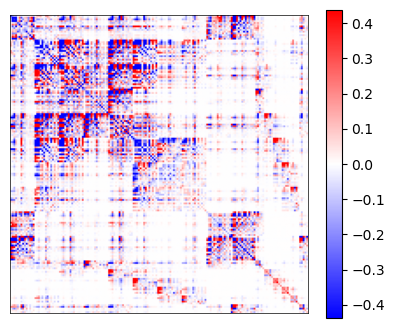

np.float64(0.43693001719664226)

In [15]:
matshow(cur_dft.init_ham - matrix_transform_single(sample.init_ham, sample.atoms.cpu().squeeze().numpy(), convention="e3nn_to_pyscf_def2svp").detach().cpu().numpy())

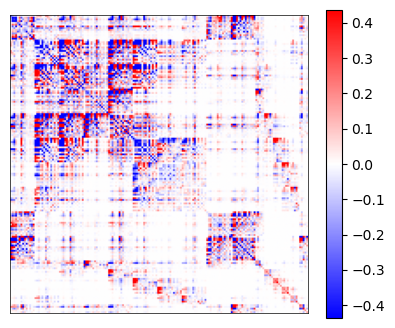

np.float64(0.4368271549932879)

In [16]:
matshow(cur_dft.pred_ham - pred_ham)

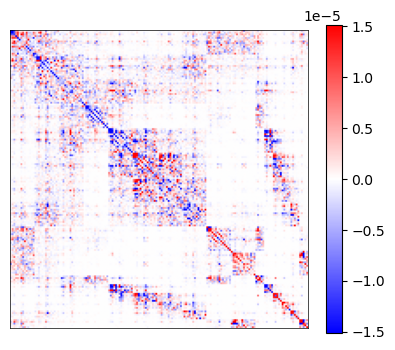

np.float64(1.5143704108311341e-05)

In [17]:
matshow(pred_ham-target_ham_transformed)

In [18]:
sample_batch = Batch.from_data_list([sample]).cuda()
sample_batch = cur_model.post_processing(sample_batch, cur_model.default_type)
sample_batch = cur_model.corrupt(sample_batch)
outputs2 = cur_model.forward(sample_batch, sample_batch.init_ham)
pred_ham2 = outputs2["hamiltonian"].detach().cpu().numpy()

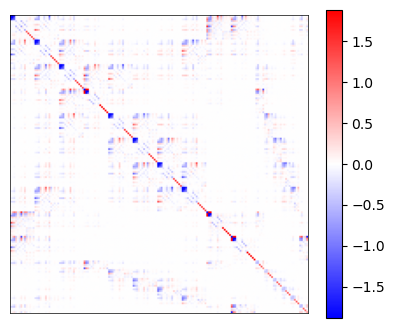

np.float64(1.8812762711211874)

In [19]:
matshow(pred_ham2)

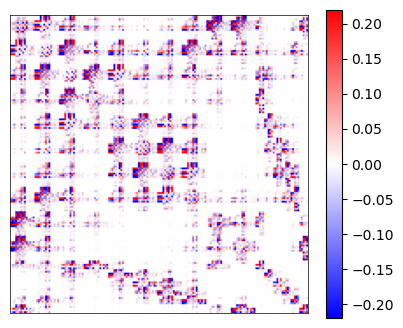

np.float64(0.21934672075856498)

In [20]:
matshow(pred_ham-target_ham_db)

In [21]:
atoms = sample.atoms.cpu().squeeze().numpy()
coords = sample.pos.cpu().numpy()
mol = cur_dft._mol(atoms, data_pos2 * pos_conversion, "def2-SVP")

In [22]:
mf = cur_dft.RKS(mol)
calc_overlap2 = torch.tensor(mf.get_ovlp())
# mf2 = cur_dft.RKS(mol)

In [23]:
mf_init_dm = mf.init_guess_by_minao()
mf_init_ham = mf.get_fock(dm=mf_init_dm)

In [24]:
cur_dft.init_mf

In [25]:
mf_init_ham - cur_dft.init_ham

array([[ 0.37993164,  0.15000422,  0.07137492, ...,  0.01040828,
        -0.00473592,  0.00299413],
       [ 0.15000422,  0.63985595,  0.43123674, ...,  0.14703052,
        -0.03135753,  0.05436613],
       [ 0.07137492,  0.43123674,  0.34746604, ...,  0.19710847,
         0.00607062,  0.10010463],
       ...,
       [ 0.01040828,  0.14703052,  0.19710847, ..., -0.42284202,
        -0.12180058, -0.13841083],
       [-0.00473592, -0.03135753,  0.00607062, ..., -0.12180058,
        -0.16141575, -0.06431681],
       [ 0.00299413,  0.05436613,  0.10010463, ..., -0.13841083,
        -0.06431681, -0.08542741]], shape=(170, 170))

In [26]:
energy = mf.kernel()
print(energy, mf.cycles, mf.xc)
# print(sample.energy)

-495.0885182999425 15 PBE


In [27]:
pred_ham_dm0 = calc_dm0_from_ham(sample.atoms, calc_overlap2, torch.tensor(pred_ham), output_res=False, transform=False)

In [28]:
cur_dft.direct_energy_force(sample_mol, model_length_unit="ang", gpu4pyscf=False, filtering=False)

(np.float64(-469.4358702314655),
 array([[-1.03357802e+02,  2.16415895e+01,  1.17243365e+02],
        [-6.79095659e+02, -1.62457417e+02, -4.00212418e+02],
        [ 4.70036443e+02,  3.19528828e+01, -7.88893092e+02],
        [ 3.19049004e+00, -4.34389562e+01,  6.17940160e+01],
        [-1.10836692e+02, -4.07080962e+01,  5.43177513e+02],
        [ 4.14166866e+02, -1.36319348e+01,  4.76660665e+02],
        [ 6.75019651e+01,  1.76734429e+02, -9.26686851e+01],
        [-3.57091355e+01, -2.46313938e+01,  2.23201159e+01],
        [-3.50676822e+01,  1.58619211e+01, -1.32353764e+01],
        [ 4.48677940e+00, -8.28813976e+00,  1.11170524e+01],
        [-2.45784167e+01,  7.86700455e+00,  2.08276105e+01],
        [ 2.90286762e+00, -7.96591276e-01, -1.61458016e+00],
        [ 2.34528964e+01,  1.58678912e+00,  1.09185551e+01],
        [ 6.34229713e+00,  9.44908631e+00,  1.21000245e+01],
        [ 6.92318469e-01,  9.61124162e-01, -3.30367304e+00],
        [-4.12721519e+00,  2.78982543e+01,  2.376923

In [29]:
pred_ham_dm0 = calc_dm0_from_ham(sample.atoms, calc_overlap2, torch.tensor(cur_dft.pred_ham), output_res=False, transform=False)

In [30]:
mf.energy_tot(pred_ham_dm0)

np.float64(-396.5944326630113)

In [31]:
cur_dft.mf.energy_tot(pred_ham_dm0)

np.float64(1933438.7201454202)

In [32]:
calc_fock2 = mf.get_fock(dm=mf.make_rdm1())

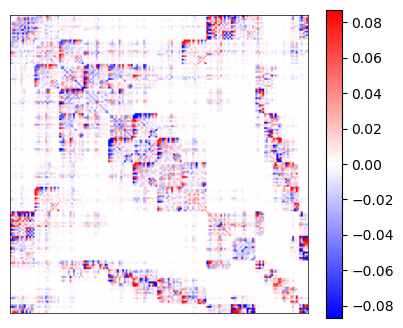

np.float64(0.08694898294786688)

In [33]:
matshow(calc_fock2-pred_ham)

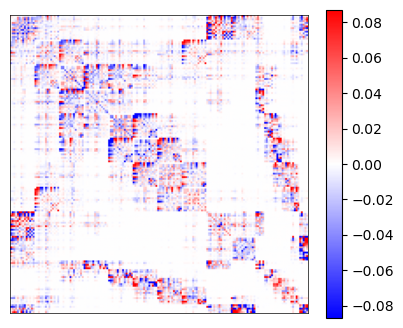

np.float64(0.08694941885979267)

In [34]:
matshow(calc_fock2-target_ham_transformed)

In [35]:
mol2 = cur_dft._mol(atoms, coords*pos_conversion, "def2-SVP")
mf2 = cur_dft.RKS(mol2)

In [36]:
gt_ham = sample.hamiltonian.detach().cpu()

In [37]:
cur_ovlp = sample.overlap.detach().cpu()

In [38]:
convention = "e3nn_to_pyscf_def2svp"

In [39]:
gt_ham_transformed = matrix_transform_single(gt_ham, atoms, convention=convention)

In [40]:
gt_density, gt_res = calc_dm0_from_ham_(atoms, calc_overlap2, gt_ham_transformed.detach().cpu(), output_res=True)
gt_density2, gt_res2 = calc_dm0_from_ham(atoms, cur_ovlp, gt_ham.detach().cpu(), output_res=True)

In [41]:
# mf2 = mf2.density_fit()

In [42]:
energy2 = mf2.energy_tot(gt_density)
print(energy2)

-478.3636981641117


In [43]:
import md.scflow_calculator

In [44]:
calculator = md.scflow_calculator.SCFlowRKSCalculator(functional="pbe", )

In [45]:
calculator.set_model(cur_ckpt, mf_init_functional="pbe", density_fit=True, model_length_unit="ang", init_density_fit=True)

INFO     [__init__.py:104] >> model_args: {'in_node_features': 1, 'sh_lmax': 4, 'hidden_size': 128,                
         'bottle_hidden_size': 32, 'num_gnn_layers': 3, 'max_radius': 15, 'num_nodes': 10, 'radius_embed_dim': 16, 
         'max_T': 15, 'use_block_S': False, 'use_block_H': False, 'ham_dim': 24, 'ham_hidden': 288, 'dataset_type':
         'qh9', 'num_ham_gnn_layers': 2}

Setting device to cuda


INFO     [base_module.py:128] >> use_init_hamiltonian: False

INFO     [base_module.py:129] >> use_init_hamiltonian_residue: True

INFO     [base_module.py:130] >> ema_start_epoch: -1

INFO     [base_module.py:131] >> qh9: False

INFO     [base_module.py:132] >> test_mode: test

INFO     [flow_module.py:211] >> init_p0_type: expand

model trained on dataset:  rmd-salicylic_acid
ode_steps: 1
Model length unit are not consistent with the model. Model length unit: ang, Model length unit: bohr


In [46]:
ase_atoms = md.scflow_calculator.QHData_to_atoms(sample, unit="ang")
calculator.calculate(ase_atoms, ["energy", "forces"], system_changes=None, filtering=False, gt_tol=1e-8, pred_tol=1e-3)

{'energy': np.float64(-495.0885146689932),
 'forces': array([[ 0.02198166,  0.06728826,  0.02307196],
        [ 0.00775219, -0.06836092, -0.02849592],
        [ 0.03177901,  0.02919403,  0.01179213],
        [ 0.01701351,  0.03564828,  0.00131071],
        [-0.05250574,  0.06414121,  0.02006063],
        [-0.01912118, -0.05765469,  0.01667514],
        [-0.01900936,  0.02250894, -0.02931478],
        [ 0.02368552, -0.01041227,  0.02992748],
        [-0.03190163, -0.01886161, -0.00738721],
        [ 0.035767  , -0.00863658,  0.01762531],
        [ 0.01158523,  0.0066636 , -0.00120962],
        [ 0.02373728, -0.02749259, -0.02929486],
        [ 0.00970363, -0.00847018,  0.0055641 ],
        [ 0.00330473, -0.01816847,  0.0016137 ],
        [-0.03105924,  0.01234311, -0.01123459],
        [-0.03271093, -0.01977736, -0.02077919]])}

In [47]:
sample_mol = cur_dft.get_mol(sample.atoms, data_pos2 * pos_conversion)
cur_dft.direct_energy_force(sample_mol, model_length_unit="ang", gpu4pyscf=False)

(np.float64(-495.08851466348415),
 array([[ 0.02198153,  0.06728765,  0.0230718 ],
        [ 0.00775207, -0.06836112, -0.0284959 ],
        [ 0.031779  ,  0.02919331,  0.0117922 ],
        [ 0.01701338,  0.03564892,  0.00131065],
        [-0.05250576,  0.06414147,  0.02006056],
        [-0.01912115, -0.05765491,  0.01667522],
        [-0.01900911,  0.02250894, -0.0293149 ],
        [ 0.02368555, -0.01041222,  0.02992766],
        [-0.03190144, -0.01886133, -0.00738716],
        [ 0.03576692, -0.00863627,  0.01762535],
        [ 0.01158554,  0.00666354, -0.00120957],
        [ 0.02373721, -0.02749252, -0.02929485],
        [ 0.00970358, -0.00847019,  0.0055641 ],
        [ 0.00330482, -0.01816837,  0.00161369],
        [-0.03105948,  0.01234325, -0.01123466],
        [-0.03271097, -0.01977738, -0.02077919]]))

In [48]:
cur_dft.mf.xc, calculator.mf.xc

('PBE', 'pbe')

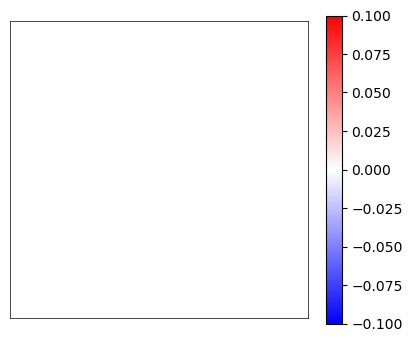

np.float64(0.0)

In [49]:
matshow(calculator.init_dm - cur_dft.init_dm)

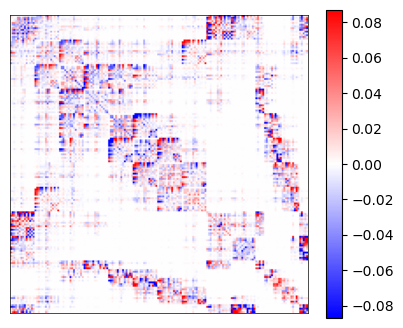

np.float64(0.08694927165225391)

In [50]:
matshow(calculator.pred_ham - target_ham_transformed)

In [51]:
abs(calculator.init_ham - cur_dft.init_ham).mean()

np.float64(1.6633769537151621e-15)

In [52]:
calculator.init_mf.get_fock(dm=mf_init_dm) - cur_dft.init_ham

array([[ 2.84217094e-14,  3.37507799e-14,  1.46549439e-14, ...,
        -1.38777878e-17, -4.33680869e-18, -2.60208521e-18],
       [ 3.37507799e-14,  2.48689958e-14,  1.06581410e-14, ...,
         0.00000000e+00,  3.33066907e-16, -1.55431223e-15],
       [ 1.46549439e-14,  1.06581410e-14,  0.00000000e+00, ...,
         0.00000000e+00, -3.33066907e-15, -5.44009282e-15],
       ...,
       [-1.38777878e-17,  0.00000000e+00,  0.00000000e+00, ...,
         1.59872116e-14,  1.32394096e-14,  6.99440506e-15],
       [-4.33680869e-18,  3.33066907e-16, -3.33066907e-15, ...,
         1.32394096e-14,  1.59872116e-14, -4.99600361e-16],
       [-2.60208521e-18, -1.55431223e-15, -5.44009282e-15, ...,
         6.99440506e-15, -4.99600361e-16,  3.19744231e-14]],
      shape=(170, 170))

In [53]:
calculator.pred_ham - cur_dft.pred_ham

array([[ 2.32053907e-07,  4.55264839e-08,  1.97779451e-08, ...,
        -7.29227045e-09,  2.91665198e-09, -3.55873276e-09],
       [ 4.55264839e-08,  7.86557650e-08,  1.15209704e-08, ...,
        -2.86003333e-08,  6.71405903e-09, -1.24246604e-08],
       [ 1.97779451e-08,  1.15209704e-08,  2.47359508e-08, ...,
        -5.74832373e-08, -1.71815156e-08, -3.08747679e-08],
       ...,
       [-7.29227045e-09, -2.86003333e-08, -5.74832373e-08, ...,
         1.01076863e-07,  9.05589661e-08,  1.01617097e-07],
       [ 2.91665195e-09,  6.71405920e-09, -1.71815155e-08, ...,
         9.05589661e-08,  5.68234182e-08,  7.69626300e-08],
       [-3.55873282e-09, -1.24246603e-08, -3.08747681e-08, ...,
         1.01617097e-07,  7.69626301e-08,  1.38264793e-07]],
      shape=(170, 170))

In [54]:
calculator.pred_ham

array([[-1.00264487e+01, -3.48788176e+00, -1.65432521e+00, ...,
         1.04181892e-02, -4.73832188e-03,  2.99366928e-03],
       [-3.48788176e+00, -1.80156878e+00, -1.25287652e+00, ...,
         1.41613454e-01, -2.53497242e-02,  4.48490417e-02],
       [-1.65432521e+00, -1.25287652e+00, -1.06637755e+00, ...,
         1.86490071e-01,  2.29878143e-02,  6.47683102e-02],
       ...,
       [ 1.04181892e-02,  1.41613454e-01,  1.86490071e-01, ...,
         8.91818551e-01, -1.18829407e-01, -1.16735240e-01],
       [-4.73832188e-03, -2.53497242e-02,  2.29878143e-02, ...,
        -1.18829407e-01,  1.14406834e+00, -4.64818708e-02],
       [ 2.99366928e-03,  4.48490417e-02,  6.47683102e-02, ...,
        -1.16735240e-01, -4.64818708e-02,  1.15805683e+00]],
      shape=(170, 170))

In [55]:
calculator.pred_dm0

array([[ 2.08505550e+00, -1.89298230e-01, -6.71937534e-02, ...,
        -8.98495252e-04, -4.00927134e-03, -8.34931471e-04],
       [-1.89298230e-01,  6.47987960e-01,  1.36838366e-01, ...,
        -1.00356394e-03,  9.58868292e-03,  1.08627062e-05],
       [-6.71937534e-02,  1.36838366e-01,  1.67897561e-01, ...,
         3.85504397e-03, -1.25090803e-03,  6.11484019e-03],
       ...,
       [-8.98495252e-04, -1.00356394e-03,  3.85504397e-03, ...,
         3.80042141e-03,  9.02715175e-04,  9.11955647e-04],
       [-4.00927134e-03,  9.58868292e-03, -1.25090803e-03, ...,
         9.02715175e-04,  1.37100277e-03,  3.65369726e-04],
       [-8.34931471e-04,  1.08627062e-05,  6.11484019e-03, ...,
         9.11955647e-04,  3.65369726e-04,  1.61065544e-03]],
      shape=(170, 170))

In [56]:
calculator.pred_mo_energy

array([-1.88247895e+01, -1.87821374e+01, -1.87586497e+01, -1.00336916e+01,
       -9.96474214e+00, -9.92395239e+00, -9.91985119e+00, -9.91587564e+00,
       -9.91126569e+00, -9.90405054e+00, -1.02356429e+00, -9.82778570e-01,
       -9.00911946e-01, -7.86454329e-01, -7.07587145e-01, -6.68661829e-01,
       -6.03849441e-01, -5.64270941e-01, -5.42124594e-01, -4.93151673e-01,
       -4.60433541e-01, -4.46106892e-01, -4.34202507e-01, -4.21181052e-01,
       -4.09055014e-01, -3.89358635e-01, -3.77144501e-01, -3.57364362e-01,
       -3.38003648e-01, -3.34635722e-01, -3.05877743e-01, -2.97753011e-01,
       -2.82606440e-01, -2.44225213e-01, -2.43028852e-01, -2.05595520e-01,
       -9.28463316e-02, -4.04015270e-02, -9.45665358e-03,  7.21871926e-03,
        3.75739627e-02,  6.76622989e-02,  9.82698371e-02,  1.00398665e-01,
        1.14315823e-01,  1.22428654e-01,  1.72392935e-01,  2.00456401e-01,
        2.07579417e-01,  2.33763483e-01,  2.65724015e-01,  2.85432888e-01,
        2.99598946e-01,  

In [57]:
calculator.pred_mo_coeff

array([[-1.18279658e-04, -3.47382271e-05,  1.46623548e-04, ...,
        -3.18256354e-02,  2.08852984e-02,  1.12706787e-02],
       [-1.53802072e-03,  5.03990713e-04,  2.16217916e-03, ...,
         2.42540537e-01, -5.33970750e-02, -5.59442330e-02],
       [-1.07006992e-02,  1.19420797e-02,  7.50587962e-03, ...,
         6.30569655e-01, -5.35680074e-01, -3.35357194e-01],
       ...,
       [-1.66301463e-03,  5.52129452e-05, -2.51989979e-04, ...,
        -1.73451715e-01, -5.91755068e-01, -5.43168020e-02],
       [-1.13034449e-03,  1.38340023e-04, -7.86815869e-05, ...,
        -1.59506887e-01, -2.59051848e-01, -3.12038491e-02],
       [-6.25386141e-04, -1.72948229e-05, -1.57491590e-04, ...,
        -7.03804587e-02, -2.49288043e-01, -1.83720641e-02]],
      shape=(170, 170))

In [58]:
import json
# save as json
res = {
    "atoms": sample.atoms.cpu().squeeze().numpy().tolist(),
    "pos": sample.pos.cpu().numpy().tolist(),
    "pred_ham": calculator.pred_ham.tolist(),
    "pred_dm0": calculator.pred_dm0.tolist(),
    "pred_mo_energy": calculator.pred_mo_energy.tolist(),
    "pred_mo_coeff": calculator.pred_mo_coeff.tolist(),
}

with open("rmd-salicylic_acid_sample.json", "w") as f:
    json.dump(res, f)

In [59]:
print(cur_dft.mf.energy_tot(cur_dft.pred_dm0))
print(cur_dft.mf.energy_tot(calculator.pred_dm0))

-495.08851466348426
-495.08851466899307


In [60]:
calculator.mf.density_fit().energy_tot(calculator.pred_dm0)

np.float64(-495.0885146689933)